In [1]:
!hostname
# !pip install scikit-image

bell-a021.rcac.purdue.edu


In [2]:
###### This code is to track all blocking events ######
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import cv2
import copy
import matplotlib.path as mpath
import pickle
import glob
from netCDF4 import Dataset
from skimage import feature, segmentation, measure
from collections import defaultdict
import sys

### A function to calculate distance between two grid points on earth ###
from math import radians, cos, sin, asin, sqrt
 
def haversine(lon1, lat1, lon2, lat2): # 
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # transform decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
 
    # haversine equation
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # earth radius
    return c * r * 1000


In [3]:
def plotting(LWAlaweyer,lawyer,linecorr='k'):

    fig = plt.figure(figsize=[8,4])
    plt.contourf(lon,lat_NH,LWAlaweyer, 20, extend="both", cmap='Reds') 
    plt.contour(lon,lat_NH,lawyer, colors=linecorr, linewidths=1) 
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

def plotting2L(LWAlaweyer,lawyer1,lawyer2,linecorr1='b',linecorr2='g'):

    fig = plt.figure(figsize=[8,4])
    plt.contourf(lon,lat_NH,LWAlaweyer, 20, extend="both", cmap='Reds') 
    plt.contour(lon,lat_NH,lawyer1, colors=linecorr1, linewidths=1) 
    plt.contour(lon,lat_NH,lawyer2, colors=linecorr2, linewidths=1)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()


In [4]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

In [7]:
duration_lists = {}

for dtname in ["ERA5", "MERRA2", "JRA3Q"]:
        
    yearname = yearnameList[dtname]
    OUTDIR = OUT_DIR_List[dtname]
    reflat = latrefFile[dtname]
    reflon = lonrefFile[dtname]
    timereff = timerefFile[dtname]

    lat = np.load(reflat)
    lon = np.load(reflon)
    lat_mid = int(len(lat)/2) + 1 #91
    lat_NH = lat[lat_mid:len(lat)] # NH only!

    print(lat_NH)
    print(lon)
    nlon = len(lon)
    nlat = len(lat)
    nlat_NH =len(lat_NH)

    ### Time Management ###
    start_year, end_year = map(int, yearname.split('_'))
    Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
    Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
    Date = list(Date0['date'])
    nday = len(Date)

    # read in the pkl
    with open(f"{OUTDIR}/{dtname}_SingleRidge_BlockingTotal_date_ridge.pkl", "rb") as f:
        BlockingTotal_date_ridge = pickle.load(f)
    with open(f"{OUTDIR}/{dtname}_SingleRidge_BlockingTotal_label_ridge.pkl", "rb") as f:
        BlockingTotal_label_ridge = pickle.load(f)

    ## Newly define B-index (2d: time, lon) and use it to identify blockings in 6 sectors ---------------
    # instantaneous blocking frequency along the longitude
    Blocking_freq2_ridge = np.zeros((nday, nlat_NH, nlon)) # (time, lat, lon)
    for n in np.arange(len(BlockingTotal_date_ridge)):
        for d in np.arange(len(BlockingTotal_date_ridge[n])):
            date_index = Date.index(BlockingTotal_date_ridge[n][d])
            Blocking_freq2_ridge[date_index] += BlockingTotal_label_ridge[n][d].astype(float)

    # define B index and calculate the sector blocking event frequency
    # Sector blocking is then defined to occur if B is positive for at least 15 degree of longitude within the sector. 
    # A sector blocking episode is said to occur if sector blocking occurs for at least 4 consecutive days.
    # B index re-define: based on the label (Blocking_frq2_ridge), 
    # if the blocking covers more than 10 degree of latitude (45-65N) then B = 1, else B = 0 at that longitude
    B_index = np.zeros((nday, nlon))
    lat_inds = np.where((lat_NH >= 45) & (lat_NH <= 65))[0]
    for d in np.arange(nday):
        for lon_i in np.arange(nlon):
            lb = Blocking_freq2_ridge[d, :, lon_i]
            lb = lb[lat_inds]
            lon_inds = np.where(lb > 0)[0] # find the lon indices that have blocked over this lat range
            if len(lon_inds) > 10:
                B_index[d, lon_i] = 1
    print(np.shape(B_index))

    dlat = dlon = 1
    # then define the sector blocking event (should be no more than 1 event in one sector in one day)
    sectordurationList = []
    for (a, b) in [(270, 360), (0, 45), (45, 120), (90, 150), (150, 225), (210, 270)]:
        mask = (lon >= a) & (lon <= b)
        d = 0
        while d < nday:
            # judge if B_index[d, mask] > 0 covers more than 15 degree of longitude
            if np.count_nonzero(B_index[d, mask] > 0) * dlon >= 15:
                consec_days = 1
                d_next = d + 1
                # find the consecutive days
                while d_next < nday and np.count_nonzero(B_index[d_next, mask] > 0) * dlon >= 15:
                    consec_days += 1
                    d_next += 1
                sectordurationList.append(consec_days)
                d = d_next
            else:
                d += 1

    print(len(sectordurationList))

    duration_lists[dtname] = sectordurationList


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 

In [9]:
print(duration_lists)

{'ERA5': [3, 7, 1, 3, 3, 2, 2, 2, 8, 4, 2, 1, 2, 1, 1, 1, 4, 1, 1, 1, 1, 4, 2, 7, 3, 2, 1, 1, 2, 7, 1, 13, 7, 5, 6, 1, 2, 4, 2, 3, 1, 4, 4, 14, 3, 2, 10, 4, 9, 2, 1, 1, 1, 4, 1, 1, 5, 9, 2, 2, 2, 2, 3, 1, 5, 1, 2, 9, 3, 2, 3, 9, 2, 5, 1, 1, 1, 3, 1, 2, 2, 3, 1, 1, 5, 2, 1, 1, 3, 1, 2, 2, 4, 6, 23, 2, 7, 3, 2, 3, 1, 2, 4, 3, 3, 1, 1, 1, 1, 1, 1, 2, 1, 1, 17, 5, 5, 3, 4, 2, 5, 17, 1, 3, 4, 3, 2, 6, 1, 2, 4, 1, 10, 1, 6, 5, 1, 1, 4, 8, 1, 1, 1, 1, 6, 1, 3, 1, 7, 9, 3, 7, 1, 1, 4, 1, 3, 7, 8, 4, 2, 1, 4, 2, 2, 2, 1, 2, 1, 4, 2, 17, 12, 1, 2, 4, 2, 1, 3, 3, 2, 4, 4, 1, 3, 1, 2, 2, 1, 1, 2, 2, 5, 1, 5, 13, 5, 1, 2, 17, 4, 4, 4, 4, 1, 3, 1, 1, 2, 1, 1, 4, 3, 8, 1, 3, 7, 2, 10, 5, 6, 3, 1, 3, 2, 3, 4, 2, 4, 6, 6, 3, 1, 15, 2, 4, 1, 1, 1, 3, 1, 8, 1, 5, 8, 3, 1, 15, 6, 3, 9, 14, 2, 1, 3, 2, 4, 7, 3, 1, 4, 6, 1, 1, 6, 6, 2, 4, 15, 8, 10, 14, 4, 2, 1, 1, 2, 6, 2, 1, 3, 5, 1, 1, 5, 3, 4, 3, 1, 1, 1, 2, 4, 6, 2, 10, 9, 3, 5, 2, 3, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 6, 13, 2, 2, 2, 1, 2, 1, 1, 1

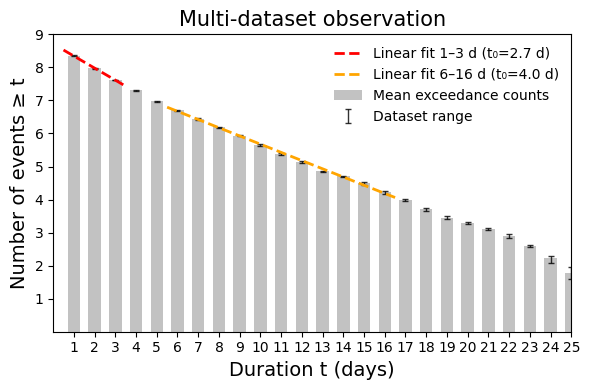

In [16]:
# ---------- prepare multi-dataset counts ----------
max_d = max(np.max(v) for v in duration_lists.values())
durations = np.arange(1, max_d + 1)

counts_all = []
for dtname, dlist in duration_lists.items():
    dlist = np.asarray(dlist)
    counts = np.array([np.sum(dlist >= t) for t in durations])
    counts_all.append(counts)

counts_stack = np.stack(counts_all, axis=0)

counts_mean = counts_stack.mean(axis=0)
counts_min  = counts_stack.min(axis=0)
counts_max  = counts_stack.max(axis=0)

yerr = np.vstack([
    counts_mean - counts_min,
    counts_max - counts_mean
])

# ---------- plot ----------
plt.figure(figsize=(6, 4))

plt.bar(
    durations, counts_mean,
    width=0.6, alpha=0.7,
    color='darkgray', edgecolor='None',
    label='Mean exceedance counts'
)

m_err = counts_min > 0

plt.errorbar(
    durations[m_err], counts_mean[m_err],
    yerr=yerr[:, m_err],
    fmt='none',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    alpha=0.8,
    label='Dataset range'
)

# plt.fill_between(
#     durations[m_err],
#     counts_min[m_err],
#     counts_max[m_err],
#     color='black',
#     alpha=0.18,
#     label='Dataset range'
# )

plt.xticks(np.arange(1, max_d + 1, 2))
plt.xlabel('Duration t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)

ax = plt.gca()
ax.set_yscale('log', base=np.e)
ax.set_ylim(bottom=1)

ytop = ax.get_ylim()[1]
kmax = int(np.ceil(np.log(ytop)))
yticks = np.exp(np.arange(1, kmax + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(1, kmax + 1))

ax.set_title('Multi-dataset observation', fontsize=15)

def fit_and_plot(dmin, dmax, color, label_prefix):
    sel = (durations >= dmin) & (durations <= dmax)
    x = durations[sel]
    y = counts_mean[sel]

    m = y > 0
    x = x[m]
    y = y[m]

    if x.size < 2:
        return

    b, a = np.polyfit(x, np.log(y), 1)
    xfit = np.array([dmin - 0.5, dmax + 0.5], dtype=float)
    yfit = np.exp(a + b * xfit)

    ax.plot(
        xfit, yfit, '--', lw=2, color=color,
        label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)'
    )

fit_and_plot(1, 3, 'red', 'Linear fit')
fit_and_plot(6, 16, 'orange', 'Linear fit')

plt.xlim(0, 25)
plt.xticks(np.arange(1, 26, 1))

ax.legend(frameon=False, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./FINAL_figures/Nature_Fig4a_witherrorbar.png', dpi=300)
plt.show()


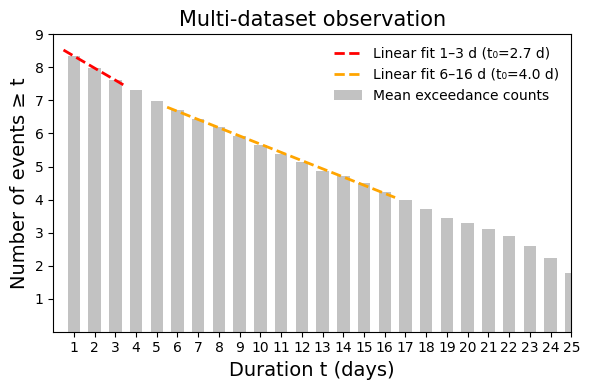

In [17]:
# ---------- prepare multi-dataset counts ----------
max_d = max(np.max(v) for v in duration_lists.values())
durations = np.arange(1, max_d + 1)

counts_all = []
for dtname, dlist in duration_lists.items():
    dlist = np.asarray(dlist)
    counts = np.array([np.sum(dlist >= t) for t in durations])
    counts_all.append(counts)

counts_stack = np.stack(counts_all, axis=0)

counts_mean = counts_stack.mean(axis=0)
counts_min  = counts_stack.min(axis=0)
counts_max  = counts_stack.max(axis=0)

yerr = np.vstack([
    counts_mean - counts_min,
    counts_max - counts_mean
])

# ---------- plot ----------
plt.figure(figsize=(6, 4))

plt.bar(
    durations, counts_mean,
    width=0.6, alpha=0.7,
    color='darkgray', edgecolor='None',
    label='Mean exceedance counts'
)

m_err = counts_min > 0

# plt.errorbar(
#     durations[m_err], counts_mean[m_err],
#     yerr=yerr[:, m_err],
#     fmt='none',
#     ecolor='black',
#     elinewidth=1,
#     capsize=2,
#     alpha=0.8,
#     label='Dataset range'
# )

# plt.fill_between(
#     durations[m_err],
#     counts_min[m_err],
#     counts_max[m_err],
#     color='black',
#     alpha=0.18,
#     label='Dataset range'
# )

plt.xticks(np.arange(1, max_d + 1, 2))
plt.xlabel('Duration t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)

ax = plt.gca()
ax.set_yscale('log', base=np.e)
ax.set_ylim(bottom=1)

ytop = ax.get_ylim()[1]
kmax = int(np.ceil(np.log(ytop)))
yticks = np.exp(np.arange(1, kmax + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(1, kmax + 1))

ax.set_title('Multi-dataset observation', fontsize=15)

def fit_and_plot(dmin, dmax, color, label_prefix):
    sel = (durations >= dmin) & (durations <= dmax)
    x = durations[sel]
    y = counts_mean[sel]

    m = y > 0
    x = x[m]
    y = y[m]

    if x.size < 2:
        return

    b, a = np.polyfit(x, np.log(y), 1)
    xfit = np.array([dmin - 0.5, dmax + 0.5], dtype=float)
    yfit = np.exp(a + b * xfit)

    ax.plot(
        xfit, yfit, '--', lw=2, color=color,
        label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)'
    )

fit_and_plot(1, 3, 'red', 'Linear fit')
fit_and_plot(6, 16, 'orange', 'Linear fit')

plt.xlim(0, 25)
plt.xticks(np.arange(1, 26, 1))

ax.legend(frameon=False, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./FINAL_figures/Nature_Fig4a_noerrorbar.png', dpi=300)
plt.show()
